In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Accuracy: 0.703125

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.67      0.60        42
           1       0.82      0.72      0.77        86

    accuracy                           0.70       128
   macro avg       0.68      0.69      0.68       128
weighted avg       0.72      0.70      0.71       128



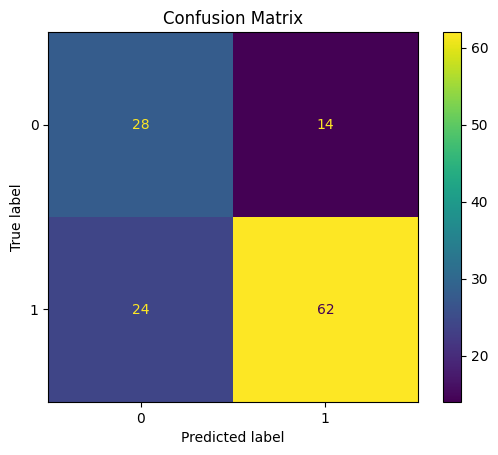

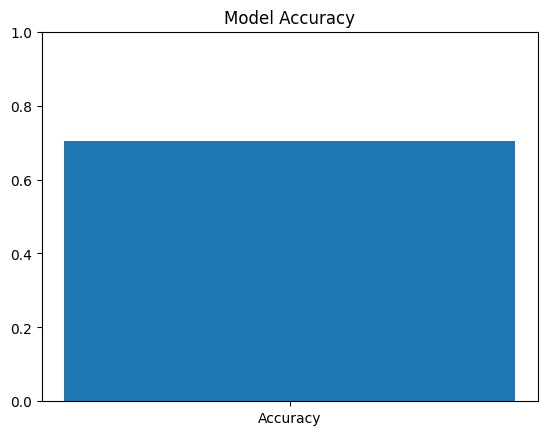

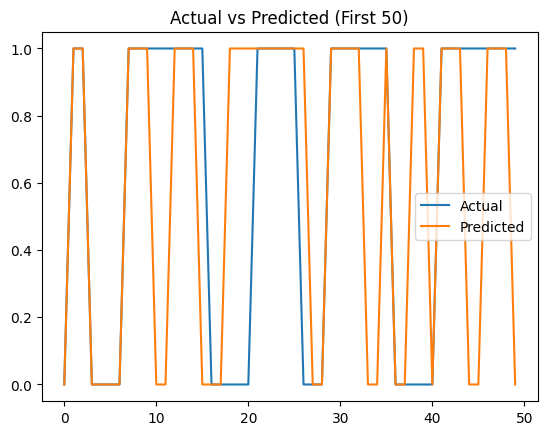

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Load data
train = pd.read_csv('/content/drive/MyDrive/ML/dataset12.csv')
test = pd.read_csv('/content/drive/MyDrive/ML/testdata12 (1).csv')

# Split features and labels (last column = target)
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]

X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SVC model
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

#Accuracy Bar
plt.figure()
plt.bar(['Accuracy'], [acc])
plt.title("Model Accuracy")
plt.ylim(0, 1)
plt.show()

#Graph 3: Actual vs Predicted (first 50)
plt.figure()
plt.plot(y_test.values[:50], label='Actual')
plt.plot(y_pred[:50], label='Predicted')
plt.title("Actual vs Predicted (First 50)")
plt.legend()
plt.show()